## Imports and settings

In [4]:
import pandas as pd
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import base64
from pathlib import Path

In [2]:
pd.set_option('display.max_colwidth', None)

## Import data

In [17]:
msoa_gdf = gpd.read_file('../data/raw/MSOA_(2021)_EW_BSC_V3_to_Rural_Urban_Classification.geojson') \
    .to_crs(27700)

In [18]:
msoa_to_lad_lookup = pd.read_csv('../data/raw/MSOA_(2011)_to_MSOA_(2021)_to_Local_Authority_District_(2022)_Exact_Fit_Lookup_for_EW_(V2).csv')

In [19]:
lad_to_pfa_lookup = pd.read_csv('../data/raw/Local_Authority_District_to_Community_Safety_Partnerships_to_Police_Force_Areas_(December_2022)_Lookup_in_England_and_Wales.csv')

In [20]:
pfa_names_lookup = pd.read_csv('../data/raw/pfa_names_lookup.csv')

In [11]:
def get_data_from_csv(archive_month, street_or_outcomes='street'):
    folder = Path(f'../data/raw/{archive_month}')

    months = []
    for item in folder.iterdir():
        if item.is_dir():
            months.append(item.name)

    for month in months:
        dfs = []
        folder_path = f'../data/raw/{archive_month}/{month}/'
        files = os.listdir(folder_path)
        for file in files:
            # Outcomes are not available for the Police Service of Northern Ireland.
            if file.endswith(f'{street_or_outcomes}.csv') and 'northern-ireland' not in file:
                if street_or_outcomes == 'street':
                    df = pd.read_csv(
                        folder_path + file,
                        usecols=['Crime ID', 'Longitude', 'Latitude', 'Crime type', 'Last outcome category', 'Reported by']
                    )
                elif street_or_outcomes == 'outcomes':
                    df = pd.read_csv(
                        folder_path + file,
                        usecols=['Crime ID', 'Outcome type', 'Reported by']
                    )
                df = df.drop_duplicates()
                df['Crime ID'] = df['Crime ID'].map(lambda x: base64.b64encode(bytes.fromhex(x)).decode("utf-8") if not pd.isna(x) else None)

                dfs.append(df)  

        df = pd.concat(dfs)
        df.to_parquet(f'../data/processed/1. parquet/{month}-{street_or_outcomes}.parquet', engine="pyarrow", compression="zstd")
            
        print(f'Saved {month} to parquet')

In [ ]:
%%time

for archive_month in ['2017-04', '2020-04', '2023-04', '2026-04']:
    get_data_from_csv(
        archive_month=archive_month,
        street_or_outcomes='street'
    )

## create coordinate to MSOA lookup

In [22]:
# create MSOA to PFA lookup
msoa_to_pfa_lookup = msoa_to_lad_lookup \
    .merge(
        lad_to_pfa_lookup,
        how='left',
        on='LAD22CD'
    ) \
    .merge(
        pfa_names_lookup,
        how='left',
        on='PFA22NM'
    )[['MSOA21CD', 'filename']] \
    .drop_duplicates()

In [37]:
def coords_to_msoa(start_date='2010-12', end_date='2026-04'):
    """
    Take indexed csvs and map the location to MSOA
    """
    
    months = pd.date_range(start_date, end_date, freq="MS").strftime("%Y-%m").tolist()

    for month in months:
        street = pd.read_parquet(f'../data/processed/1. parquet/{month}-street.parquet', engine='pyarrow')

        coords = street[['Longitude', 'Latitude']].drop_duplicates()
        coords_gdf = gpd.GeoDataFrame(
            coords,
            geometry=gpd.points_from_xy(coords['Longitude'], coords['Latitude']),
            crs="EPSG:4326"
        ).to_crs(27700)
        coords_to_msoa_lookup = gpd.sjoin(
            coords_gdf,
            msoa_gdf[['MSOA21CD', 'MSOA21NM', 'geometry']],
            how='left',
            predicate='within'
        )

        # Assign MSOA21CD to each crime
        street = street.merge(
            coords_to_msoa_lookup[['Latitude', 'Longitude', 'MSOA21CD']],
            how='left',
            on=['Latitude', 'Longitude']
        )
        street = street.drop(['Latitude', 'Longitude'], axis=1)

        street.to_parquet(f'../data/processed/2. msoa/{month}-street.parquet', engine="pyarrow", compression="zstd")

        print(f'Saved {month} to parquet')

In [ ]:
%%time

coords_to_msoa()

## Create heatmaps

In [16]:
street = pd.read_csv(f'../data/processed/2. msoa/2023-04-street.csv')

In [19]:
# group the crimes by MSOA
street_grouped = street.groupby(['MSOA21CD']).agg(crime_count=('Crime ID', 'nunique')).reset_index()

In [21]:
# create gdf
gdf = msoa_gdf.merge(
    street_grouped,
    how='inner',
    on='MSOA21CD'
)

<Axes: >

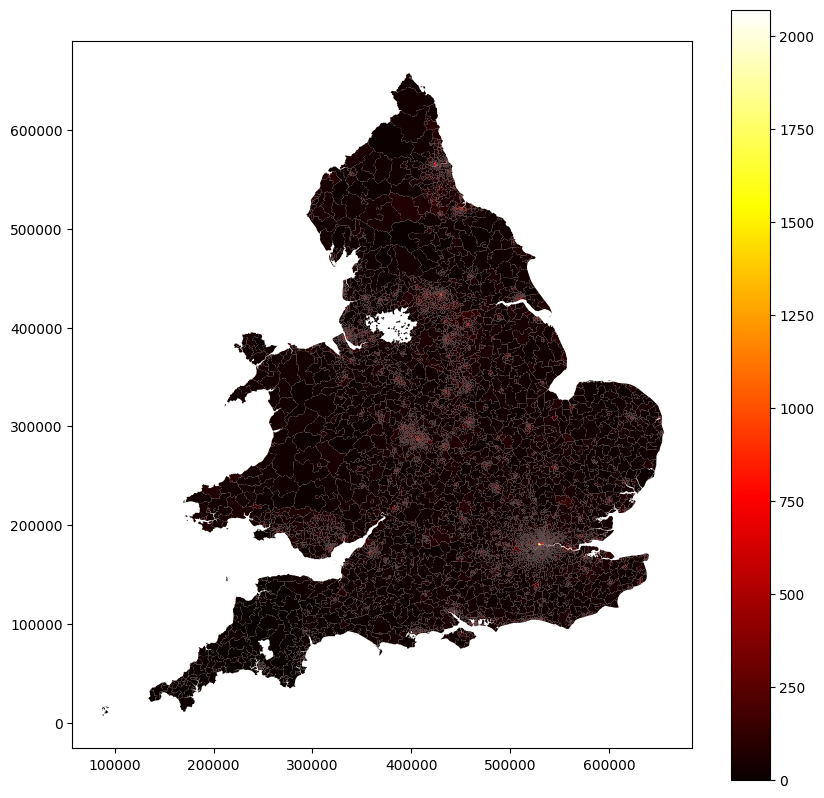

In [25]:
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, column='crime_count', cmap='hot', legend=True)

In [ ]:
months = pd.date_range('2023-04', '2026-03', freq="MS").strftime("%Y-%m").tolist()

min_crime_count = 0
max_crime_count = street_grouped['crime_count'].max()

for month in months:
    fig, ax = plt.subplots(figsize=(10, 10))
    gdf.plot(ax=ax, column=month, cmap='hot', vmin=min_crime_count, vmax=max_crime_count, legend=True)
    # police_areas_gdf[police_areas_gdf['PFA23NM'] == 'Wiltshire'].plot(ax=ax, facecolor='none', edgecolor='yellow')
    fig.savefig(f'heatmaps/{month}.png')
    plt.close(fig)
    print(f'month: {month} saved')

#police_areas_gdf.plot(ax=ax, color='blue')
#wiltshire_msoa_gdf.plot(ax=ax, column='2024-01', cmap='hot')


In [ ]:
# get the ids in street that appear more than once in outcomes
street_ids = street[['Crime ID', 'Month']].value_counts()
outcomes_ids = outcomes[['Crime ID', 'Month']].value_counts()

In [ ]:
ids_with_multiple_dates = (
    street.groupby('Crime ID')['Month']
      .nunique()
      .loc[lambda s: s > 1]
      .index
)
ids_with_multiple_dates

In [ ]:
df = street.merge(outcomes, on='Crime ID', how='inner')

In [ ]:
df[df.duplicated('Crime ID', keep=False)]

In [ ]:
street[street['Crime ID'].isin(ids_with_multiple_dates)]['Reported by'].value_counts()

# Archive

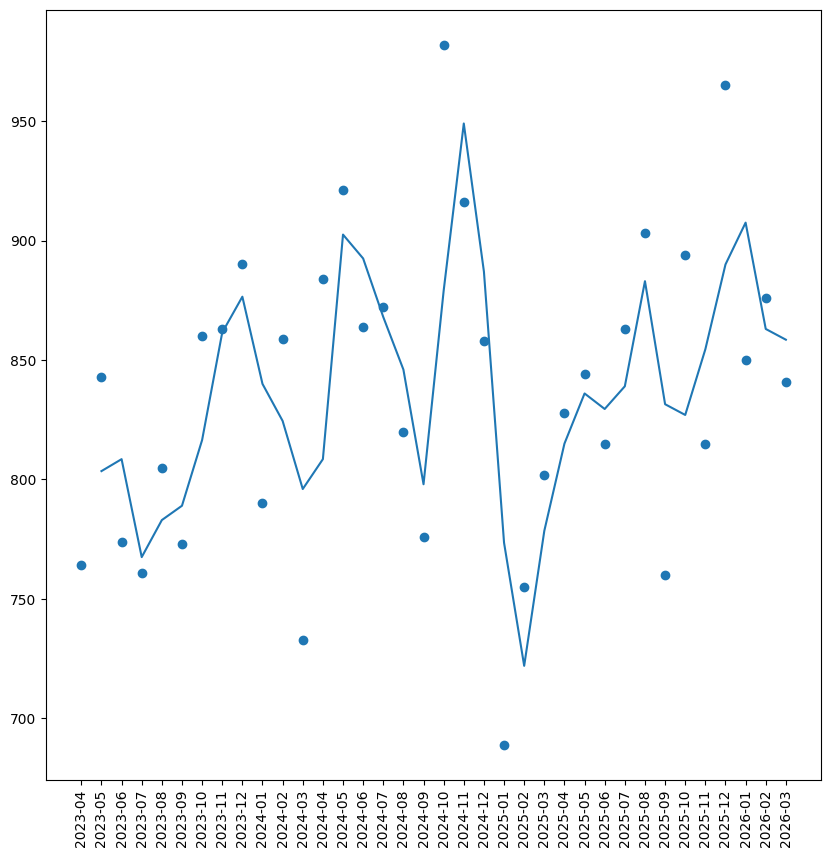

In [119]:
fig, ax = plt.subplots(figsize=(10, 10))

['E02000972', 'E02000977']

test = df[df['MSOA21CD'].isin(['E02000001'])].copy()
#test = df.copy()
test = test.groupby('month')['crime_count'].sum().reset_index()
plt.xticks(rotation=90)
ax.scatter(x=test['month'], y=test['crime_count'])

rolling = test["crime_count"].rolling(window=2, center=True).mean()
ax.plot(test['month'], rolling)